<a href="https://colab.research.google.com/github/annabarsukovaca-stack/Machine-Learning-Practice/blob/main/Ch3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#setup
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [2]:
#load the MNISt data set
mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X, y = mnist["data"], mnist["target"]

In [3]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


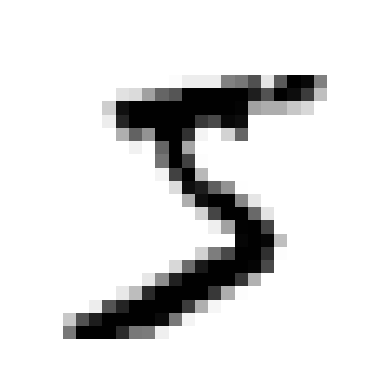

In [4]:
#display one digit
some_digit = X[0]

some_digit_image = some_digit.reshape(28, 28)

plt.imshow(
    some_digit_image,
    cmap=mpl.cm.binary,
    interpolation="nearest"
)

plt.axis("off")
plt.show()

In [5]:
print(y[0])

5


basically, the dataset stores each image in a long list of 784 pixel values, so reshape(28, 28) turns it back to image

In [6]:
y = y.astype(np.uint8)

labels initially come as text (example: "5"), but we convert into numbers to simplify

In [7]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [8]:
#all digits recognition
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [9]:
#train SGD classifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(
    random_state=42
)

sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [10]:
sgd_clf.predict([some_digit])

array([ True])

In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

print(scores)

[0.95035 0.96035 0.9604 ]


In [12]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
  def fit(self, X, y=None):
    return self

  def predict(self, X):
    return np.zeros(
        (len(X), 1),
        dtype=bool
    )

In [13]:
never_5_clf = Never5Classifier()

cross_val_score(
    never_5_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

array([0.91125, 0.90855, 0.90915])

this means that around 90% of the images are not 5, so accuracy only is not a good measurement

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3
)

In [15]:
from sklearn.metrics import confusion_matrix
confusion_matrix(
    y_train_5,
    y_train_pred
)

array([[53892,   687],
       [ 1891,  3530]])

In [16]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(
    y_train_5,
    y_train_pred
)

recall = recall_score(
    y_train_5,
    y_train_pred
)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8370879772350012
Recall: 0.6511713705958311


In [17]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_train_5,
    y_train_pred
)

print("F1 Score:", f1)

F1 Score: 0.7325171197343847


In [18]:
y_scores = sgd_clf.decision_function([some_digit])

print(y_scores)

[2164.22030239]


In [19]:
threshold = 0

y_some_digit_pred = (
    y_scores > threshold
)

print(y_some_digit_pred)

[ True]


In [22]:
threshold = 8000

y_some_digit_pred = (y_scores > threshold)

print(y_some_digit_pred)

[False False False ...  True False False]


In [21]:
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)

In [23]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    y_scores
)

In [24]:
def plot_precision_recall_vs_threshold(
    precisions,
    recalls,
    thresholds
):

    plt.plot(
        thresholds,
        precisions[:-1],
        label="Precision"
    )

    plt.plot(
        thresholds,
        recalls[:-1],
        label="Recall"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid()

    plt.show()

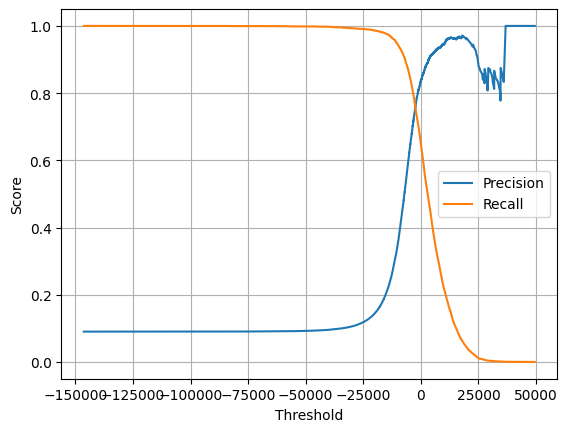

In [25]:
plot_precision_recall_vs_threshold(
    precisions,
    recalls,
    thresholds
)

In [26]:
threshold_90_precision = thresholds[
    np.argmax(precisions >= 0.90)
]

print(threshold_90_precision)

3370.0194991439557


In [28]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

print(
    "Precision:",
    precision_score(
        y_train_5,
        y_train_pred_90
    )
)

print(
    "Recall:",
    recall_score(
        y_train_5,
        y_train_pred_90
    )
)

Precision: 0.9000345901072293
Recall: 0.4799852425751706


In [30]:
#download MNIST and import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# Download the MNIST dataset
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


70,000 images of handwritten digits

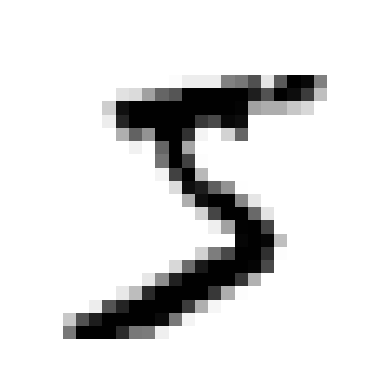

Label: 5


In [32]:
some_digit = X[0]

some_digit_image = some_digit.reshape(28, 28)

plt.imshow(
    some_digit_image,
    cmap=mpl.cm.binary,
    interpolation="nearest"
)

plt.axis("off")
plt.show()

print("Label:", y[0])

In [34]:
X_train = X[:60000]
X_test = X[60000:]

y_train = y[:60000]
y_test = y[60000:]

In [35]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [36]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

created SGDClassifier and trained it to recognize whether is 5 not a 5

In [37]:
prediction = sgd_clf.predict([some_digit])

print(prediction)

[ True]


In [38]:
print("Prediction:", prediction)
print("Actual digit:", y[0])

Prediction: [ True]
Actual digit: 5


In [39]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)
print(scores)
print("Average accuracy:", scores.mean())

[0.95035 0.96035 0.9604 ]
Average accuracy: 0.9570333333333334


trainiang data is divided into 3 parts (model trains and tests itself 3 times). Accuracy may be misleading because most digits are not 5

In [42]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.zeros(len(X), dtype=bool)

In [43]:
never_5_clf = Never5Classifier()

scores = cross_val_score(
    never_5_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

print(scores)
print("Average accuracy:", scores.mean())

[0.91125 0.90855 0.90915]
Average accuracy: 0.90965


only about 10% of the images are actually 5s, so accuracy gets around 90%

In [44]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3
)

In [45]:
#confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [46]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8370879772350012
Recall: 0.6511713705958311


when the model says "this is a 5", how often is it correct?

In [47]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)

print("F1 score:", f1)

F1 score: 0.7325171197343847


In [49]:
#decision scores
y_scores = sgd_clf.decision_function([some_digit])

print(y_scores)

[2164.22030239]


In [50]:
threshold = 0

y_some_digit_pred = (y_scores > threshold)

print(y_some_digit_pred)

[ True]


In [51]:
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)

getting model decision score for every training image instead of only True False

In [52]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train_5,
    y_scores
)

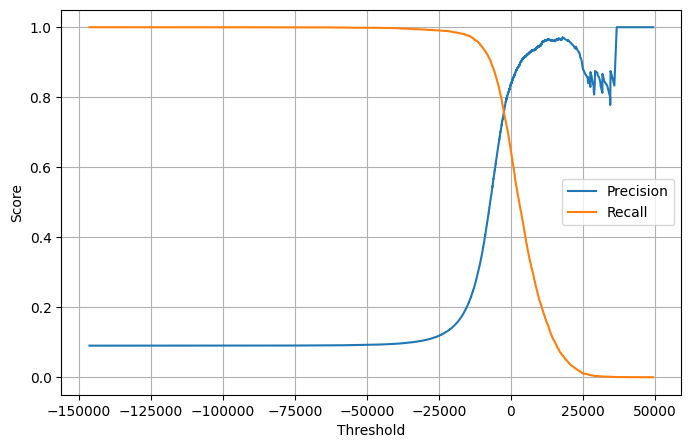

In [54]:
#recall curve
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

when threshold increases, precision usually increases and recall decreases. Name: precision/recall tradeoff

In [55]:
threshold_90_precision = thresholds[
    np.argmax(precisions >= 0.90)
]

print(threshold_90_precision)

3370.0194991439557


In [56]:
y_train_pred_90 = (
    y_scores >= threshold_90_precision
)

In [57]:
print(
    "Precision:",
    precision_score(y_train_5, y_train_pred_90)
)

print(
    "Recall:",
    recall_score(y_train_5, y_train_pred_90)
)

Precision: 0.9000345901072293
Recall: 0.4799852425751706


approximately 90% precision is achieved by increasing the treshold. The model becomes more careful when predicting a 5, but it also misses more real 5s